<a href="https://colab.research.google.com/github/sanjusaladi19/Real-Estate-ML-Predictor/blob/main/Linear_Regression(Real-Estate-ML-Predictor).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


import the libraries
---



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score,mean_absolute_error



importing the dataset


In [43]:
housing=fetch_openml(name="house_prices", as_frame=True)
df=housing.frame
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

handling the missing values

In [44]:
num_col=df.select_dtypes(["number"]).columns
cate_col=df.select_dtypes(["object"]).columns
df[num_col]=df[num_col].fillna(df[num_col].median())
df[cate_col]=df[cate_col].fillna("None")


adjusting the outliers


In [45]:
df=df[df['GrLivArea']<4000]

converting the categorail data into numerical and dummies values

In [46]:
df_final=pd.get_dummies(df,drop_first=True)

splitting the data


In [51]:
x = df_final.drop('SalePrice', axis=1)
y=df_final['SalePrice']
x_test,x_train, y_test, y_train=train_test_split(x,y,test_size=0.2,random_state=42)
model=Lasso(alpha=100,max_iter=10000)
model.fit(x_train,y_train)
predictions=model.predict(x_test)
print(r2_score(y_test, predictions))
print(mean_absolute_error(y_test, predictions))


0.8738501272483176
18588.65951699139


<function matplotlib.pyplot.show(close=None, block=None)>

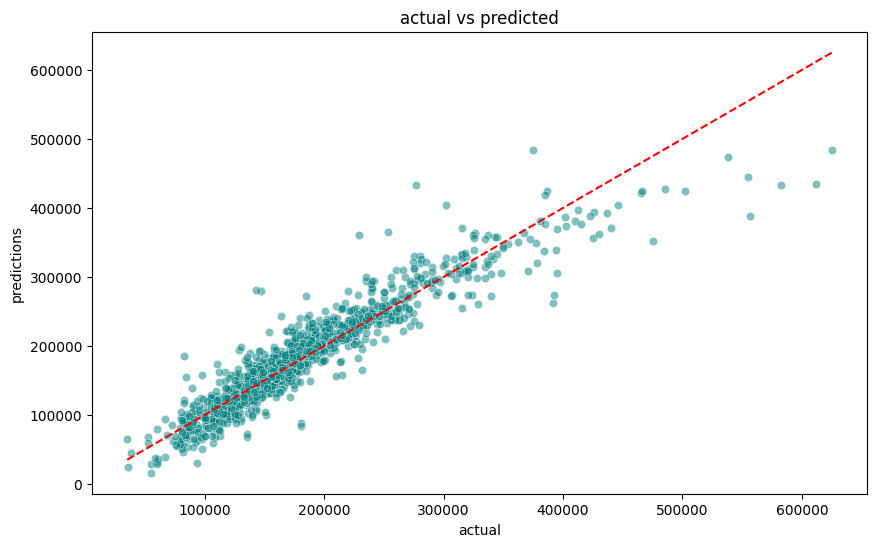

In [54]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test,y=predictions, alpha=0.5, color="teal")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"--r",)
plt.title("actual vs predicted")
plt.xlabel("actual")
plt.ylabel("predictions")
plt.show